In [1]:
import scanpy as sc
asthma_ext_path1 = "asthma_ext_diluent_data.h5ad"
asthma_ext_path2 = "asthma_ext_allergen_data.h5ad"
asthma_ext_path3 = "asthma_ext_baseline_data.h5ad"
asthma_ext_adata1 = sc.read_h5ad(asthma_ext_path1)
asthma_ext_adata2 = sc.read_h5ad(asthma_ext_path2)
asthma_ext_adata3 = sc.read_h5ad(asthma_ext_path3)
# 위 세 데이터를 row-wise로 합치기
asthma_ext_adata = asthma_ext_adata1.concatenate(asthma_ext_adata2, asthma_ext_adata3, batch_key="condition", batch_categories=["diluent", "allergen", "baseline"])

/tmp/ipykernel_1707854/3859189686.py:9: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  asthma_ext_adata = asthma_ext_adata1.concatenate(asthma_ext_adata2, asthma_ext_adata3, batch_key="condition", batch_categories=["diluent", "allergen", "baseline"])


In [ ]:
# 각 adata의 cell 개수 확인 후 합쳐진 adata의 cell 개수 확인
print(f"adata1 cell count: {asthma_ext_adata1.n_obs}")
print(f"adata2 cell count: {asthma_ext_adata2.n_obs}")
print(f"adata3 cell count: {asthma_ext_adata3.n_obs}")
print(f"Combined adata cell count: {asthma_ext_adata.n_obs}")


adata1 cell count: 12284
adata2 cell count: 17462
adata3 cell count: 22406
Combined adata cell count: 52152


In [3]:
# 합쳐진 adata 저장
asthma_ext_adata.write_h5ad("asthma_ext_combined_data.h5ad")

In [12]:
print(asthma_ext.var_names[:10])

import pandas as pd
import numpy as np

def remap_var_names_to_ppi_symbol_and_drop(
    adata,
    alias_path="/data2/project/bin_jip/Biomarker/data/9606.protein.aliases.v12.0.txt",
    network_path="/data2/project/bin_jip/Biomarker/data/ppi_network.tsv",
):
    # 1) load minimal columns
    alias_df = pd.read_csv(
        alias_path,
        sep="\t",
        usecols=["string_protein_id", "alias"],
        dtype={"string_protein_id": "string", "alias": "string"},
    ).dropna(subset=["string_protein_id", "alias"])

    network_df = pd.read_csv(
        network_path,
        sep="\t",
        usecols=["protein1", "protein2"],
        dtype={"protein1": "string", "protein2": "string"},
    ).dropna(subset=["protein1", "protein2"])

    # normalize
    alias_df["string_protein_id"] = alias_df["string_protein_id"].str.strip()
    alias_df["alias"] = alias_df["alias"].str.strip().str.upper()

    ppi_symbols = pd.Index(network_df["protein1"]).append(pd.Index(network_df["protein2"]))
    ppi_symbols = set(ppi_symbols.astype(str).str.strip().str.upper().tolist())

    # 2) alias -> string_protein_id (deterministic first)
    alias_to_spid = (
        alias_df[["alias", "string_protein_id"]]
        .drop_duplicates(subset="alias", keep="first")
        .set_index("alias")["string_protein_id"]
    )

    # 3) string_protein_id -> gene symbol (must exist in PPI symbols)
    spid_to_symbol = (
        alias_df.loc[alias_df["alias"].isin(ppi_symbols), ["string_protein_id", "alias"]]
        .sort_values(["string_protein_id", "alias"])
        .drop_duplicates(subset="string_protein_id", keep="first")
        .set_index("string_protein_id")["alias"]
    )

    # 4) vectorized mapping for var_names
    var_orig = pd.Series(adata.var_names.astype(str), index=np.arange(adata.n_vars), name="var_name_original")
    var_norm = var_orig.str.strip().str.upper()

    spid_series = var_norm.map(alias_to_spid)
    symbol_series = spid_series.map(spid_to_symbol)

    keep_mask = symbol_series.notna().to_numpy()
    removed_count = int((~keep_mask).sum())
    mapped_count = int(keep_mask.sum())

    # 5) drop unmapped vars + replace var_names
    adata_new = adata[:, keep_mask].copy()
    adata_new.var["var_name_original"] = var_orig[keep_mask].to_numpy()
    adata_new.var["string_protein_id"] = spid_series[keep_mask].to_numpy()
    adata_new.var_names = pd.Index(symbol_series[keep_mask].to_numpy())

    dup_before_unique = int(adata_new.var_names.duplicated().sum())
    if dup_before_unique > 0:
        adata_new.var_names_make_unique()

    final_ppi_overlap = len(set(adata_new.var_names.astype(str).str.upper()) & ppi_symbols)

    print(f"[mapping] original n_vars: {adata.n_vars}")
    print(f"[mapping] mapped: {mapped_count}, removed: {removed_count}")
    print(f"[mapping] duplicated symbols before make_unique: {dup_before_unique}")
    print(f"[mapping] final n_vars: {adata_new.n_vars}")
    print(f"[mapping] final var_names overlap with PPI symbols: {final_ppi_overlap}")

    report = pd.DataFrame(
        {
            "var_name_original": var_orig,
            "string_protein_id": spid_series,
            "mapped_symbol": symbol_series,
            "kept": symbol_series.notna(),
        }
    )
    return adata_new, report

asthma_ext_mapped, map_report = remap_var_names_to_ppi_symbol_and_drop(asthma_ext)
map_report.to_csv("/data2/project/bin_jip/Biomarker/data/asthma_ext/varname_mapping_report.tsv", sep="\t", index=False)
asthma_ext_mapped.write_h5ad(f"/data2/project/bin_jip/Biomarker/data/asthma_ext/{asthma_ext_path}")


Index(['AL627309.1', 'AL627309.3', 'AL627309.4', 'AL732372.1', 'AL669831.2',
       'AL669831.5', 'FAM87B', 'LINC00115', 'FAM41C', 'AL645608.7'],
      dtype='object', name='feature')
[mapping] original n_vars: 28304
[mapping] mapped: 14849, removed: 13455
[mapping] duplicated symbols before make_unique: 833
[mapping] final n_vars: 14849
[mapping] final var_names overlap with PPI symbols: 14016


In [ ]:
# asthma_ext log1p 변환 여부 확인
print(asthma_ext.X.max())
print(asthma_ext.X.min())
print(asthma_ext)

11.160624
0.0
AnnData object with n_obs × n_vars = 52152 × 28304
    obs: 'Channel', 'n_genes', 'n_counts', 'percent_mito', 'id', 'group', 'condition', 'cluster', 'label'
    var: 'gene_ids', 'n_cells', 'percent_cells', 'robust', 'highly_variable_features', 'mean', 'var', 'hvf_loess', 'hvf_rank'
    uns: 'Channel_colors', 'Channels', 'PCs', 'W_pca', 'W_pca_harmony', 'cell_set_clean_colors', 'cell_set_colors', 'cluster_colors', 'condition_colors', 'diffmap_evals', 'genome', 'group_colors', 'pca', 'pca_harmony_knn_distances', 'pca_harmony_knn_indices', 'pca_knn_distances', 'pca_knn_indices', 'neighbors', 'umap', 'id_colors', 'label_colors'
    obsm: 'X_diffmap', 'X_pca', 'X_pca_harmony', 'X_phi', 'X_umap'
    varm: 'de_res_updated'
    obsp: 'distances', 'connectivities'


In [21]:
# asthma_ext의 column별 value counts 확인. unique values 30개 이하인 column들만 출력
for col in asthma_ext.obs.columns:
    if asthma_ext.obs[col].nunique() <= 30:
        print(f"{col}: {asthma_ext.obs[col].value_counts()}")
        

Channel: Channel
500015_ANA_Pre    4364
500030_AA_Ag      4244
500012_ANA_Pre    4156
500021_AA_Dil     3511
500023_AA_Pre     3497
500024_ANA_Pre    3457
500012_ANA_Dil    2959
500021_AA_Ag      2847
500035_AA_Pre     2711
500023_AA_Ag      2414
500030_AA_Dil     2188
500012_ANA_Ag     2141
500024_ANA_Dil    2046
500008_ANA_Pre    1759
500024_ANA_Ag     1665
500008_ANA_Dil    1580
500035_AA_Ag      1523
500030_AA_Pre     1360
500015_ANA_Ag     1345
500008_ANA_Ag     1283
500021_AA_Pre     1102
Name: count, dtype: int64
id: id
500012    9256
500030    7792
500021    7460
500024    7168
500023    5911
500015    5709
500008    4622
500035    4234
Name: count, dtype: int64
group: group
AC    26755
AA    25397
Name: count, dtype: int64
condition: condition
Bln    22406
Ag     17462
Dil    12284
Name: count, dtype: int64
cluster: cluster
Epithelial cells    21069
CD8 T cells         13038
MNP                  8776
CD4 T cells          6361
B cells              1685
Mast cells            668

In [22]:
# column 매핑하자. 'group' column 값이 'AC'면 str '0', group='AA'면 '1'로 'label' column에 매핑
asthma_ext.obs['label'] = asthma_ext.obs['group'].map({'AC': '0', 'AA': '1'})
# asthma_ext을 h5ad 파일로 저장
asthma_ext.write_h5ad("asthma_ext_data_preprocessed.h5ad")

In [ ]:
# 'condition' column에 따라서 copy 후 따로 저장 'Bln, Ag, Dil' 있다.
for condition in asthma_ext.obs['condition'].unique():
    subset = asthma_ext[asthma_ext.obs['condition'] == condition].copy()
    subset.write_h5ad(f"asthma_ext_{condition}_data_preprocessed.h5ad")

In [25]:
bln= sc.read_h5ad("asthma_ext_Bln_data_preprocessed.h5ad")
ag= sc.read_h5ad("asthma_ext_Ag_data_preprocessed.h5ad")
dil= sc.read_h5ad("asthma_ext_Dil_data_preprocessed.h5ad")

In [26]:
# 다 column별 value counts 확인해보자 30개 이하 unique value 가지는 column들만 출력
for col in bln.obs.columns:
    if bln.obs[col].nunique() <= 30:
        print(f"BLN - {col}: {bln.obs[col].value_counts()}")
for col in ag.obs.columns:
    if ag.obs[col].nunique() <= 30:
        print(f"AG - {col}: {ag.obs[col].value_counts()}")
for col in dil.obs.columns:
    if dil.obs[col].nunique() <= 30:
        print(f"DIL - {col}: {dil.obs[col].value_counts()}")

BLN - Channel: Channel
500015_ANA_Pre    4364
500012_ANA_Pre    4156
500023_AA_Pre     3497
500024_ANA_Pre    3457
500035_AA_Pre     2711
500008_ANA_Pre    1759
500030_AA_Pre     1360
500021_AA_Pre     1102
Name: count, dtype: int64
BLN - id: id
500015    4364
500012    4156
500023    3497
500024    3457
500035    2711
500008    1759
500030    1360
500021    1102
Name: count, dtype: int64
BLN - group: group
AC    13736
AA     8670
Name: count, dtype: int64
BLN - condition: condition
Bln    22406
Name: count, dtype: int64
BLN - cluster: cluster
Epithelial cells    12748
CD8 T cells          5576
CD4 T cells          1711
MNP                  1445
B cells               607
Mast cells            165
NK cells              154
Name: count, dtype: int64
BLN - label: label
0    13736
1     8670
Name: count, dtype: int64
AG - Channel: Channel
500030_AA_Ag     4244
500021_AA_Ag     2847
500023_AA_Ag     2414
500012_ANA_Ag    2141
500024_ANA_Ag    1665
500035_AA_Ag     1523
500015_ANA_Ag    1345

/data2/project/bin_jip/miniconda3/envs/scbiomarker/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


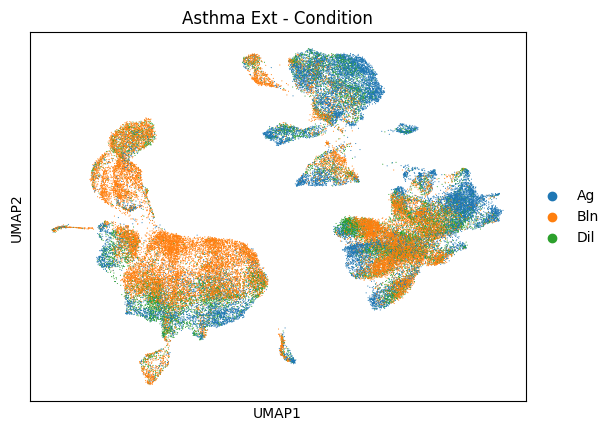

In [28]:
# 그 다음은 asthma_ext 전체 데이터로 UMAP 그려보자. color는 'condition'으로 해보자.
sc.pp.neighbors(asthma_ext)
sc.tl.umap(asthma_ext)
sc.pl.umap(asthma_ext, color='condition', title='Asthma Ext - Condition')

/data2/project/bin_jip/miniconda3/envs/scbiomarker/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


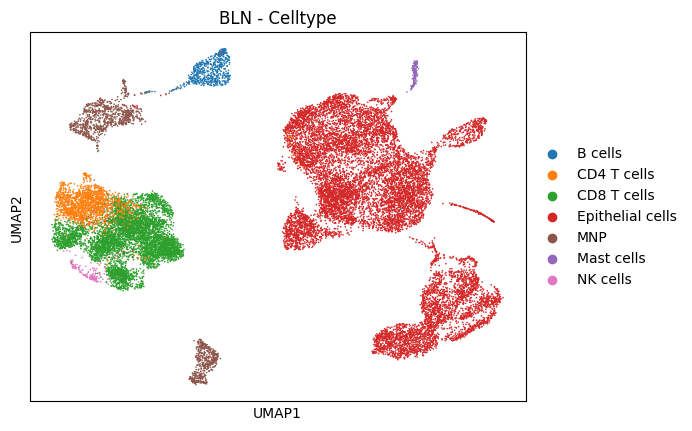

/data2/project/bin_jip/miniconda3/envs/scbiomarker/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


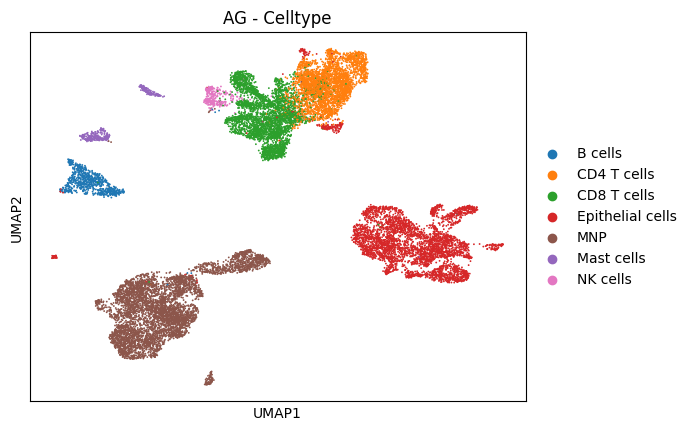

/data2/project/bin_jip/miniconda3/envs/scbiomarker/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


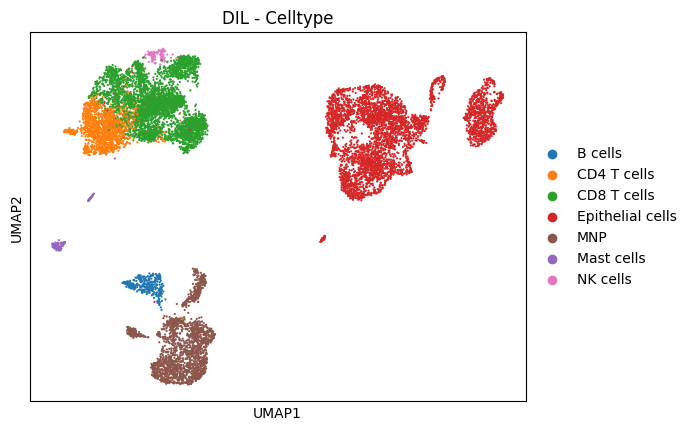

/data2/project/bin_jip/miniconda3/envs/scbiomarker/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


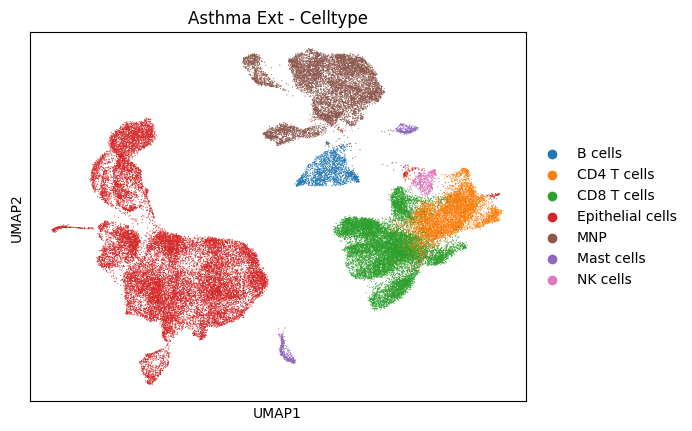

In [30]:
# 네 가지 그림 다 celltype별로 색깔 다르게 해서 그려보자. 'celltype' column이 있던데, 이걸로 color 해보자.
sc.pl.umap(bln, color='cluster', title='BLN - Celltype')
sc.pl.umap(ag, color='cluster', title='AG - Celltype')
sc.pl.umap(dil, color='cluster', title='DIL - Celltype')
sc.pl.umap(asthma_ext, color='cluster', title='Asthma Ext - Celltype')

/data2/project/bin_jip/miniconda3/envs/scbiomarker/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/data2/project/bin_jip/miniconda3/envs/scbiomarker/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


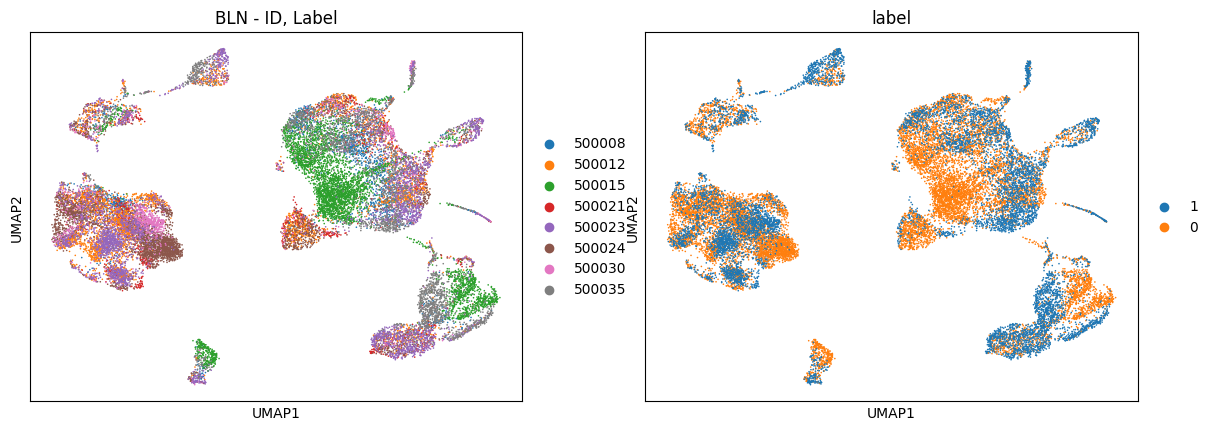

/data2/project/bin_jip/miniconda3/envs/scbiomarker/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/data2/project/bin_jip/miniconda3/envs/scbiomarker/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


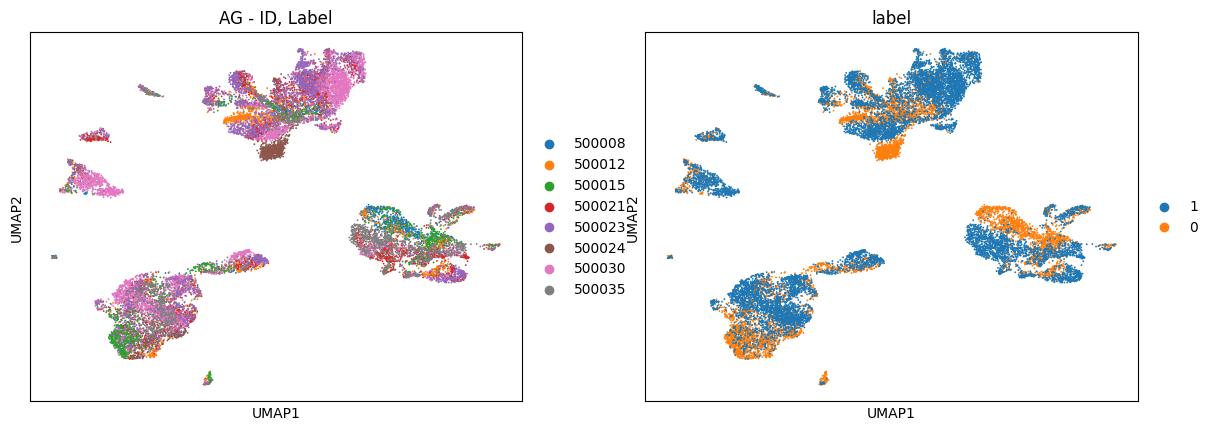

/data2/project/bin_jip/miniconda3/envs/scbiomarker/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/data2/project/bin_jip/miniconda3/envs/scbiomarker/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


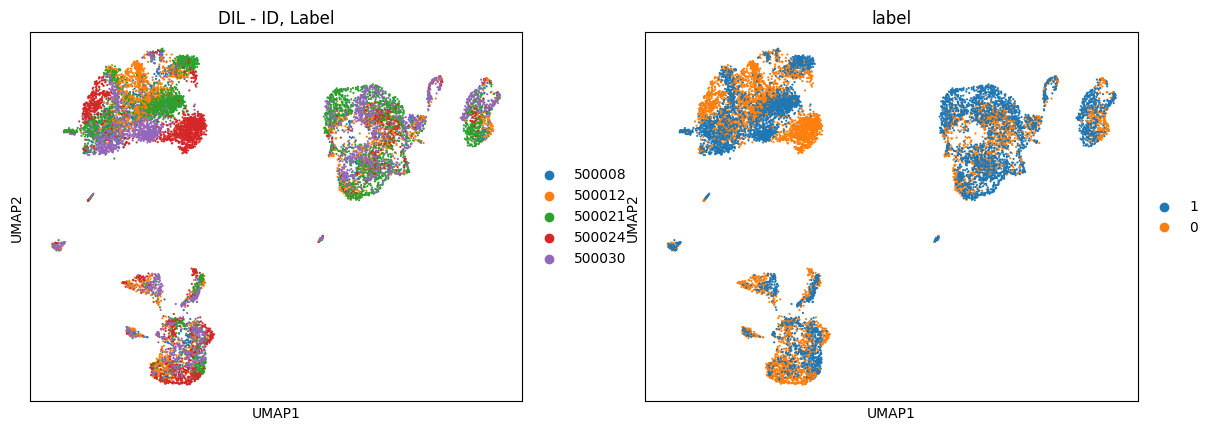

/data2/project/bin_jip/miniconda3/envs/scbiomarker/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/data2/project/bin_jip/miniconda3/envs/scbiomarker/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


/data2/project/bin_jip/miniconda3/envs/scbiomarker/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


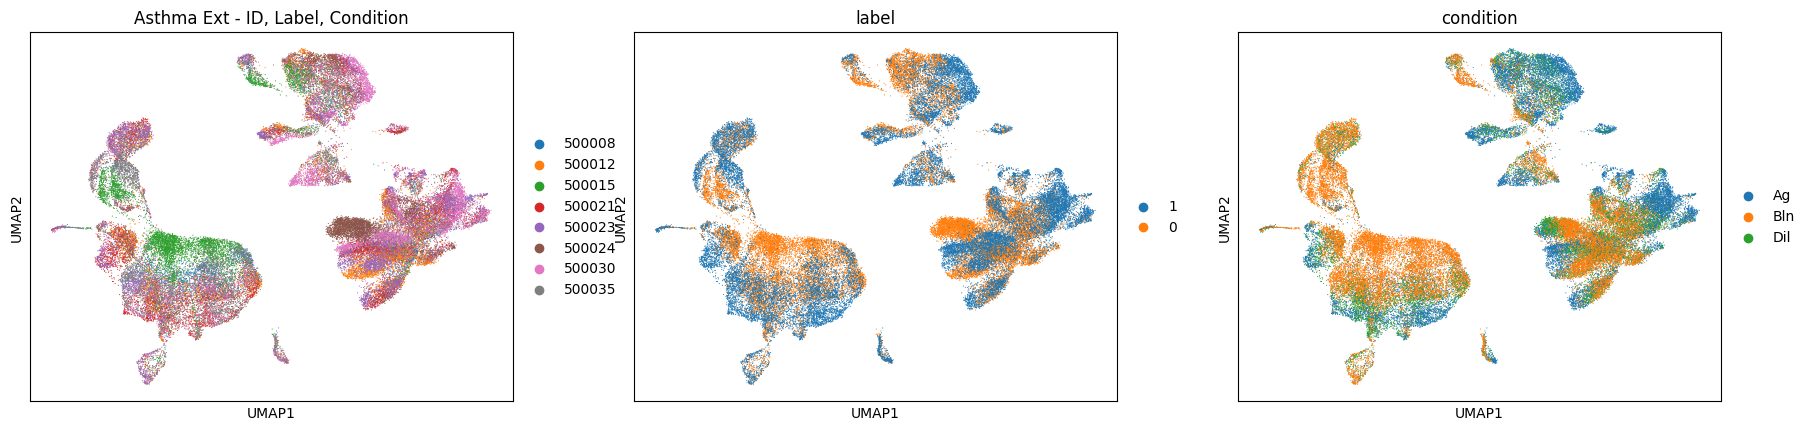

In [33]:
# id, label,  column으로도 해보자
sc.pl.umap(bln, color=['id', 'label'], title='BLN - ID, Label')
sc.pl.umap(ag, color=['id', 'label'], title='AG - ID, Label')
sc.pl.umap(dil, color=['id', 'label'], title='DIL - ID, Label')
sc.pl.umap(asthma_ext, color=['id', 'label', 'condition'], title='Asthma Ext - ID, Label, Condition')
